In [ ]:
# codigo inicial que unificou as bases de vendas e vistoria, criou as colunas de ágio absoluto e percentual, 
# e removeu os registros duplicados dos itens agrupados
# removeu os imoveis da tipologia apartamento/nao é caracteristica da empresa. Venda por convenio de outra instituicao
# teste usando o codigo da destinacao original, via onehot encoding

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

tabela = pd.read_csv("base_vendas_atividade2_final1.csv", sep=";", encoding="latin-1")
vistoria = pd.read_csv("base_vistorias_atividade2_final.csv", sep=";", encoding="latin-1")
destinacoes = pd.read_csv("base_destinacoes_atividade2_final.csv", sep=";", encoding="latin-1")

tabela = tabela.merge(
    vistoria[["CD_IMOVEL_URBANO", "SIM_SITIMO_DS"]],
    how="left",
    left_on="CD_IMOVEL",
    right_on="CD_IMOVEL_URBANO"
)


tabela = tabela.merge(
    destinacoes[["COD_DESTINACAO_IMOVEL", "TIPO_USO_DESTINACAO", "RESIDENCIAL", "COMERCIAL", "INDUSTRIAL", "INSTITUCIONAL"]],
    how="left",
    left_on="COD_DESTINACAO_IMOVEL",
    right_on="COD_DESTINACAO_IMOVEL"
)       


# # remove a coluna duplicada da chave
tabela = tabela.drop(columns=["CD_IMOVEL_URBANO", "CD_IMOVEL"])
tabela = tabela.rename(columns={"SIM_SITIMO_DS": "SITUACAO_VISTORIA"})
# tabela["SITUACAO_VISTORIA"] = tabela["SITUACAO_VISTORIA"].fillna("SEM_VISTORIA")


# # colunas que definem a duplicidade: mesmo ano, mesmo edital e mesmo item do edital (item de edital com imoveis agrupados)
cols = ["ANO_VENDA", "NR_EDITAL", "ITEM_EDITAL"]
# # máscara: True para linhas que aparecem em duplicidade (em qualquer posição do grupo)
mask_dup = tabela.duplicated(subset=cols, keep=False)
# # remove TODAS as linhas duplicadas desses grupos
tabela_sem_dups = tabela.loc[~mask_dup].copy()

# # Foram removidos 145 itens que constavam como items agrupados, de um total de 2982, restando 2837 registros 
# print("Linhas originais:", len(tabela))
# print("Linhas removidas:", mask_dup.sum())
# print("Linhas finais:", len(tabela_sem_dups))

tabela = tabela_sem_dups
tabela["NR_EDITAL"] = tabela["ANO_VENDA"].astype(str) + "-" + tabela["NR_EDITAL"].astype(str)

def br_to_float(s):
    """
    Converte número no formato BR para float:
    - remove separador de milhar (.)
    - troca decimal (,) por (.)
    """
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s == "":
        return np.nan
    s = s.replace(".", "")      # remove milhares
    s = s.replace(",", ".")     # troca decimal
    return pd.to_numeric(s, errors="coerce")

cols = ["VALOR_VENDA", "AREA_MAX_CONSTR", "AREA_BASE", "AREA", "VALOR_LAUDO"]  # ajuste
for c in cols:
    if c in tabela.columns:
        tabela[c] = tabela[c].apply(br_to_float)

# #criacao da coluna AGIO ABSOLUTO , esta coluna deve ser retirada do treino
tabela["AGIO_ABSOLUTO"] = tabela["VALOR_VENDA"] - tabela["VALOR_LAUDO"]
tabela["AGIO_PERCENTUAL"] = ((tabela["VALOR_VENDA"] - tabela["VALOR_LAUDO"]) / tabela["VALOR_LAUDO"]) * 100

#retirando os apartamentos da base (14 registros) que tem área máxima de construção igual a zero e área base igual a zero, ou seja, não tem área construída, o que é um erro de cadastro
# tabela[~(tabela["AREA_MAX_CONSTR"] == 0) & (tabela["AREA_BASE"] == 0)]
tabela = tabela[~((tabela["AREA_MAX_CONSTR"] == 0) & (tabela["AREA_BASE"] == 0))]  
tabela = tabela[~((tabela["AREA_MAX_CONSTR"] == 0) & (tabela["AREA_BASE"] == 0))]
tabela = tabela[~((tabela["CD_IMOVEL"] == 158423) | (tabela["CD_IMOVEL"] == 197972))] 

# -------------------------
# 0) DADOS (ajuste se necessário)
# -------------------------
df = tabela.copy()
df.columns = df.columns.str.strip()

TARGET = "VALOR_VENDA"


# Remover colunas que você NÃO quer usar
# (vazamento/colinearidade/dado futuro)
DROP_COLS = ["AGIO_ABSOLUTO", "AGIO_PERCENTUAL", "VALOR_LAUDO", "QTD_OFERTAS", "DS_DESTINACAO_IMOVEL"]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# Percentual 0–100 -> 0–1
if "PERCENTUAL_ENTRADA" in df.columns:
    df["PERCENTUAL_ENTRADA"] = pd.to_numeric(df["PERCENTUAL_ENTRADA"], errors="coerce") / 100.0


# Separar X e y
y = df[TARGET].copy()
X = df.drop(columns=[TARGET] + DROP_COLS)

# DS_CIDADE;DS_SETOR;COD_DESTINACAO_IMOVEL;TIPO_USO_DESTINACAO;
# Definir colunas numéricas e categóricas explicitamente
num_cols = [
    "AREA_MAX_CONSTR", "AREA_BASE", "AREA", "PERCENTUAL_ENTRADA", "RESIDENCIAL", "COMERCIAL", "INDUSTRIAL", "INSTITUCIONAL"]

num_cols = [c for c in num_cols if c in X.columns]

cat_cols = ["DS_CIDADE", "DS_SETOR", "SITUACAO_VISTORIA", "COD_DESTINACAO_IMOVEL", "ANO_VENDA", "NR_EDITAL", "TIPO_USO_DESTINACAO"]
cat_cols = [c for c in cat_cols if c in X.columns]

# Tipos (evita problemas de mixed types)
for c in cat_cols:
    X[c] = X[c].astype("string")
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)
print("Shape X:", X.shape, "| Shape y:", y.shape)



Numéricas: ['AREA_MAX_CONSTR', 'AREA_BASE', 'AREA', 'PERCENTUAL_ENTRADA', 'RESIDENCIAL', 'COMERCIAL', 'INDUSTRIAL', 'INSTITUCIONAL']
Categóricas: ['DS_CIDADE', 'DS_SETOR', 'SITUACAO_VISTORIA', 'COD_DESTINACAO_IMOVEL', 'ANO_VENDA', 'NR_EDITAL', 'TIPO_USO_DESTINACAO']
Shape X: (2823, 16) | Shape y: (2823,)


In [33]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Transformação log do preço (recomendado pela cauda longa)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


# -------------------------
# 1) PREPROCESSAMENTO
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe_sparse = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess_sparse = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", cat_pipe_sparse, cat_cols),
    ],
    remainder="drop"
)

# HistGradientBoosting não aceita sparse -> onehot denso
cat_pipe_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", cat_pipe_dense, cat_cols),
    ],
    remainder="drop"
)


In [34]:
# -------------------------
# 3) MODELO 1: RIDGE (GridSearch simples)
# -------------------------
# Ridge best params: alpha=0.1, fit_intercept=True
pipe_ridge_best = Pipeline([
    ("preprocess", preprocess_sparse),
    ("model", Ridge(alpha=0.1, fit_intercept=True, random_state=42))
])

# ExtraTrees Stage2 best params:
# max_depth=None, max_features=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=1200
pipe_et_best = Pipeline([
    ("preprocess", preprocess_sparse),
    ("model", ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=1200,
        max_depth=None,
        max_features=0.7,
        min_samples_leaf=1,
        min_samples_split=2
    ))
])

# HistGradientBoosting best params:
# l2_regularization=1.0, learning_rate=0.1, max_depth=6, max_iter=600, min_samples_leaf=10
pipe_hgb_best = Pipeline([
    ("preprocess", preprocess_dense),
    ("model", HistGradientBoostingRegressor(
        random_state=42,
        l2_regularization=1.0,
        learning_rate=0.1,
        max_depth=6,
        max_iter=600,
        min_samples_leaf=10
    ))
])


In [35]:
# ============================================================
# 5) TREINAR E AVALIAR (TESTE)
# ============================================================
def eval_test(pipe, name, piso_mape=100_000):
    pipe.fit(X_train, y_train_log)

    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)

    mae_rs  = mean_absolute_error(y_test, pred)
    rmse_rs = root_mean_squared_error(y_test, pred)
    r2_rs   = r2_score(y_test, pred)

    mape_rs = mean_absolute_percentage_error(y_test, pred)
    mask = y_test >= piso_mape
    mape_rs_piso = mean_absolute_percentage_error(y_test[mask], pred[mask]) if mask.any() else np.nan

    mae_log  = mean_absolute_error(y_test_log, pred_log)
    rmse_log = root_mean_squared_error(y_test_log, pred_log)

    print(f"\n=== {name} (TESTE) ===")
    print("MAE (R$):", mae_rs)
    print("RMSE (R$):", rmse_rs)
    print("R²:", r2_rs)
    print("MAPE (R$):", mape_rs)
    print(f"MAPE (R$) com piso >= {piso_mape}:", mape_rs_piso)
    print("MAE (log):", mae_log)
    print("RMSE (log):", rmse_log)

    return {
        "Modelo": name,
        "MAE_R$": mae_rs,
        "RMSE_R$": rmse_rs,
        "R2_R$": r2_rs,
        "MAPE_R$": mape_rs,
        f"MAPE_R$_>={piso_mape}": mape_rs_piso,
        "MAE_log": mae_log,
        "RMSE_log": rmse_log
    }

results = []
results.append(eval_test(pipe_ridge_best, "Ridge (best params)"))
results.append(eval_test(pipe_et_best, "ExtraTrees (best params)"))
results.append(eval_test(pipe_hgb_best, "HistGradientBoosting (best params)"))

res_df = pd.DataFrame(results).sort_values("MAE_R$", ascending=True)
print("\n=== RESUMO ===")
print(res_df)


=== Ridge (best params) (TESTE) ===
MAE (R$): 260142971864.9987
RMSE (R$): 6183516752144.838
R²: -2909417252736.672
MAPE (R$): 10839.72462765012
MAPE (R$) com piso >= 100000: 11961.713554521271
MAE (log): 0.442566839047287
RMSE (log): 0.8713211881358868

=== ExtraTrees (best params) (TESTE) ===
MAE (R$): 235881.13608731455
RMSE (R$): 971507.3090823584
R²: 0.9281830311414547
MAPE (R$): 0.16648370240797358
MAPE (R$) com piso >= 100000: 0.15724548985843578
MAE (log): 0.15973169828472195
RMSE (log): 0.26125508139942405

=== HistGradientBoosting (best params) (TESTE) ===
MAE (R$): 329526.62154040666
RMSE (R$): 1468337.2396000924
R²: 0.8359461022409788
MAPE (R$): 0.19258211490775912
MAPE (R$) com piso >= 100000: 0.18590639424319957
MAE (log): 0.18554814158683544
RMSE (log): 0.2845254548622875

=== RESUMO ===
                               Modelo        MAE_R$       RMSE_R$  \
1            ExtraTrees (best params)  2.358811e+05  9.715073e+05   
2  HistGradientBoosting (best params)  3.295266

In [31]:

# 1) Índices do conjunto de teste (preservados pelo train_test_split)
pipe_ridge_best.fit(X_train, y_train_log)
pipe_et_best.fit(X_train, y_train_log)
pipe_hgb_best.fit(X_train, y_train_log)

# 1) Índices do conjunto de teste (preservados pelo train_test_split)
idx_test = y_test.index

# 2) Pegar as linhas originais do dataframe (com todas as colunas que você quiser mostrar)
df_test = tabela.loc[idx_test].copy()

# 3) Previsões (modelos treinados em log)
pred_log_ridge = pipe_ridge_best.predict(X_test)
pred_log_et    = pipe_et_best.predict(X_test)
pred_log_hgb   = pipe_hgb_best.predict(X_test)

df_test["PRED_RIDGE"]      = np.expm1(pred_log_ridge)
df_test["PRED_EXTRATREES"] = np.expm1(pred_log_et)
df_test["PRED_HISTGB"]     = np.expm1(pred_log_hgb)

# 4) Erros absolutos e percentuais (comparando com o valor real)
df_test["ERRO_ABS_RIDGE"]      = (df_test["PRED_RIDGE"] - df_test["VALOR_VENDA"]).abs()
df_test["ERRO_ABS_EXTRATREES"] = (df_test["PRED_EXTRATREES"] - df_test["VALOR_VENDA"]).abs()
df_test["ERRO_ABS_HISTGB"]     = (df_test["PRED_HISTGB"] - df_test["VALOR_VENDA"]).abs()

df_test["ERRO_PCT_RIDGE"]      = df_test["ERRO_ABS_RIDGE"] / df_test["VALOR_VENDA"]
df_test["ERRO_PCT_EXTRATREES"] = df_test["ERRO_ABS_EXTRATREES"] / df_test["VALOR_VENDA"]
df_test["ERRO_PCT_HISTGB"]     = df_test["ERRO_ABS_HISTGB"] / df_test["VALOR_VENDA"]

# 5) (Opcional) Selecionar só colunas de "características" + resultados
cols_info = [
    "DS_CIDADE", "DS_SETOR", "COD_DESTINACAO_IMOVEL", "ANO_VENDA", "NR_EDITAL", "ITEM_EDITAL",
    "AREA_MAX_CONSTR", "AREA_BASE", "AREA", "PERCENTUAL_ENTRADA", "SITUACAO_VISTORIA", "VALOR_LAUDO",
    "VALOR_VENDA"
]
cols_info = [c for c in cols_info if c in df_test.columns]

cols_result = [
    "PRED_RIDGE", "PRED_EXTRATREES", "PRED_HISTGB",
    "ERRO_ABS_RIDGE", "ERRO_ABS_EXTRATREES", "ERRO_ABS_HISTGB",
    "ERRO_PCT_RIDGE", "ERRO_PCT_EXTRATREES", "ERRO_PCT_HISTGB"
]

df_vis = df_test[cols_info + cols_result].copy()

def moeda_br(v):
    if pd.isna(v):
        return ""
    s = f"{float(v):,.2f}"
    s = s.replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {s}"

def pct_br(v):
    if pd.isna(v):
        return ""
    return f"{float(v)*100:.1f}%".replace(".", ",")

cols_area = ["AREA_MAX_CONSTR", "AREA_BASE", "AREA"]
cols_area = [c for c in cols_area if c in df_vis.columns]

fmt_area = {c: "{:,.2f}".format for c in cols_area}

cols_moeda = ["VALOR_LAUDO", "VALOR_VENDA", "PRED_RIDGE", "PRED_EXTRATREES", "PRED_HISTGB",
             "ERRO_ABS_RIDGE", "ERRO_ABS_EXTRATREES", "ERRO_ABS_HISTGB"]
cols_pct = ["ERRO_PCT_RIDGE", "ERRO_PCT_EXTRATREES", "ERRO_PCT_HISTGB"]

fmt = {}
for c in cols_moeda:
    if c in df_vis.columns:
        fmt[c] = moeda_br
for c in cols_pct:
    if c in df_vis.columns:
        fmt[c] = pct_br

fmt_total = {}
fmt_total.update(fmt)        # fmt que você já tinha (moeda e %)
fmt_total.update(fmt_area)   # adiciona áreas com 2 casas

# exemplo: ordenar pelos maiores valores reais
display(df_vis.sort_values("VALOR_VENDA", ascending=False).head(30).style.format(fmt_total))

,DS_CIDADE,DS_SETOR,COD_DESTINACAO_IMOVEL,ANO_VENDA,NR_EDITAL,ITEM_EDITAL,AREA_MAX_CONSTR,AREA_BASE,AREA,PERCENTUAL_ENTRADA,SITUACAO_VISTORIA,VALOR_LAUDO,VALOR_VENDA,PRED_RIDGE,PRED_EXTRATREES,PRED_HISTGB,ERRO_ABS_RIDGE,ERRO_ABS_EXTRATREES,ERRO_ABS_HISTGB,ERRO_PCT_RIDGE,ERRO_PCT_EXTRATREES,ERRO_PCT_HISTGB
869,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2021,2021-13,5,"6,300.00","6,300.00","1,000.00",30,VAGO,"R$ 19.000.000,00","R$ 31.652.000,00","R$ 24.275.880,43","R$ 27.652.000,00","R$ 30.249.498,57","R$ 7.376.119,57","R$ 4.000.000,00","R$ 1.402.501,43","23,3%","12,6%","4,4%"
1564,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2023,2023-9,2,"6,300.00","6,300.00","1,000.00",30,VAGO,"R$ 19.600.000,00","R$ 31.000.000,00","R$ 24.376.177,45","R$ 33.000.000,00","R$ 29.309.732,71","R$ 6.623.822,55","R$ 2.000.000,00","R$ 1.690.267,29","21,4%","6,5%","5,5%"
439,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2021,2021-1,7,"5,796.00","5,796.00",920.00,5,OBSTRUIDO,"R$ 17.300.000,00","R$ 25.525.000,00","R$ 23.477.358,68","R$ 22.501.012,00","R$ 18.476.219,38","R$ 2.047.641,32","R$ 3.023.988,00","R$ 7.048.780,62","8,0%","11,8%","27,6%"
862,SANTA MARIA,POLO DESENV/ECONOMICO JUSCELINO KUBITSCHEK INDUSTRIA COMERCIO DE APOIO,60225,2021,2021-12,91,"181,131.60","75,471.50","75,471.50",5,VAGO,"R$ 23.700.000,00","R$ 24.000.003,50","R$ 146.980.539.288.901,28","R$ 11.368.890,98","R$ 10.164.495,35","R$ 146.980.515.288.897,78","R$ 12.631.112,52","R$ 13.835.508,15","612418724,4%","52,6%","57,6%"
442,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2021,2021-1,10,"5,796.00","5,796.00",920.00,5,OBSTRUIDO,"R$ 17.300.000,00","R$ 23.888.000,00","R$ 23.477.358,68","R$ 22.501.012,00","R$ 18.476.219,38","R$ 410.641,32","R$ 1.386.988,00","R$ 5.411.780,62","1,7%","5,8%","22,7%"
233,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2020,2020-11,13,"5,796.00","5,796.00",920.00,30,VAGO,"R$ 14.900.000,00","R$ 22.812.477,00","R$ 19.416.006,29","R$ 21.694.740,44","R$ 21.612.024,87","R$ 3.396.470,71","R$ 1.117.736,56","R$ 1.200.452,13","14,9%","4,9%","5,3%"
691,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2021,2021-7,2,"5,796.00","5,796.00",920.00,30,VAGO,"R$ 17.300.000,00","R$ 22.612.000,00","R$ 24.800.634,10","R$ 27.869.616,91","R$ 25.570.313,99","R$ 2.188.634,10","R$ 5.257.616,91","R$ 2.958.313,99","9,7%","23,3%","13,1%"
228,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2020,2020-11,8,"5,796.00","5,796.00",920.00,30,VAGO,"R$ 14.900.000,00","R$ 21.801.018,00","R$ 19.416.006,29","R$ 21.694.740,44","R$ 21.612.024,87","R$ 2.385.011,71","R$ 106.277,56","R$ 188.993,13","10,9%","0,5%","0,9%"
235,BRASILIA,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,1893,2020,2020-11,15,"5,796.00","5,796.00",920.00,30,OBSTRUIDO,"R$ 14.900.000,00","R$ 21.604.012,00","R$ 19.744.028,60","R$ 21.739.140,18","R$ 23.040.143,79","R$ 1.859.983,40","R$ 135.128,18","R$ 1.436.131,79","8,6%","0,6%","6,6%"
1851,BRASILIA,SETOR DE EMBAIXADAS NORTE,60308,2024,2024-2,12,"9,551.47","9,551.47","7,959.56",5,VAGO,"R$ 15.800.000,00","R$ 20.888.000,00","R$ 34.451.147,63","R$ 14.229.486,63","R$ 13.651.597,25","R$ 13.563.147,63","R$ 6.658.513,37","R$ 7.236.402,75","64,9%","31,9%","34,6%"


In [12]:
# 1) Treinar (1 fit por modelo) — rápido
pipe_ridge_best.fit(X_train, y_train_log)
pipe_et_best.fit(X_train, y_train_log)
pipe_hgb_best.fit(X_train, y_train_log)

# 2) Função para adicionar previsões + erros em um df
def adicionar_prev_e_erros(df_orig, X_features, prefix=""):
    pred_ridge = np.expm1(pipe_ridge_best.predict(X_features))
    pred_et    = np.expm1(pipe_et_best.predict(X_features))
    pred_hgb   = np.expm1(pipe_hgb_best.predict(X_features))

    df_out = df_orig.copy()
    df_out[f"{prefix}PRED_RIDGE"] = pred_ridge
    df_out[f"{prefix}PRED_EXTRATREES"] = pred_et
    df_out[f"{prefix}PRED_HISTGB"] = pred_hgb

    # erros (se tiver VALOR_VENDA)
    if "VALOR_VENDA" in df_out.columns:
        df_out[f"{prefix}ERRO_ABS_RIDGE"] = (df_out[f"{prefix}PRED_RIDGE"] - df_out["VALOR_VENDA"]).abs()
        df_out[f"{prefix}ERRO_ABS_EXTRATREES"] = (df_out[f"{prefix}PRED_EXTRATREES"] - df_out["VALOR_VENDA"]).abs()
        df_out[f"{prefix}ERRO_ABS_HISTGB"] = (df_out[f"{prefix}PRED_HISTGB"] - df_out["VALOR_VENDA"]).abs()

        df_out[f"{prefix}ERRO_PCT_RIDGE"] = df_out[f"{prefix}ERRO_ABS_RIDGE"] / df_out["VALOR_VENDA"]
        df_out[f"{prefix}ERRO_PCT_EXTRATREES"] = df_out[f"{prefix}ERRO_ABS_EXTRATREES"] / df_out["VALOR_VENDA"]
        df_out[f"{prefix}ERRO_PCT_HISTGB"] = df_out[f"{prefix}ERRO_ABS_HISTGB"] / df_out["VALOR_VENDA"]

    return df_out

# 3) Exportar TESTE (recomendado)
idx_test = y_test.index
df_test = tabela.loc[idx_test].copy()

# X_test já está pronto (mesmas features usadas no treino)
df_test_out = adicionar_prev_e_erros(df_test, X_test)

# 4) (Opcional) Exportar BASE INTEIRA (atenção: inclui treino também)
# Para isso você precisa do X inteiro (mesma engenharia de features que você usou antes do split)
# Se você ainda tem X (o dataframe de features completo) no notebook, use ele:
df_full_out = adicionar_prev_e_erros(tabela.copy(), X)

# 5) Salvar Excel com abas
arquivo = "vendas_previsoes_modelos.xlsx"
with pd.ExcelWriter(arquivo, engine="openpyxl") as writer:
    df_test_out.to_excel(writer, sheet_name="TESTE", index=False)
    # Descomente se quiser salvar a base inteira também:
    df_full_out.to_excel(writer, sheet_name="BASE_INTEIRA", index=False)

print(f"Arquivo gerado: {arquivo}")

Arquivo gerado: vendas_previsoes_modelos.xlsx


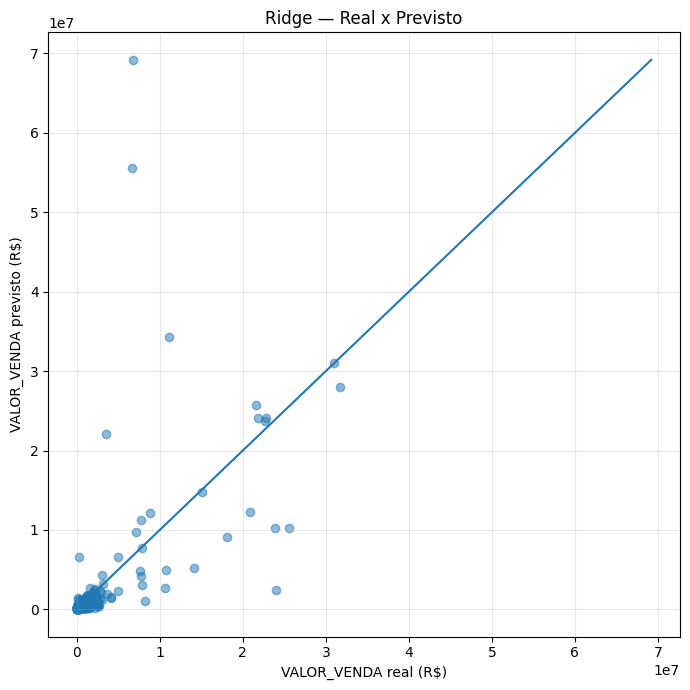

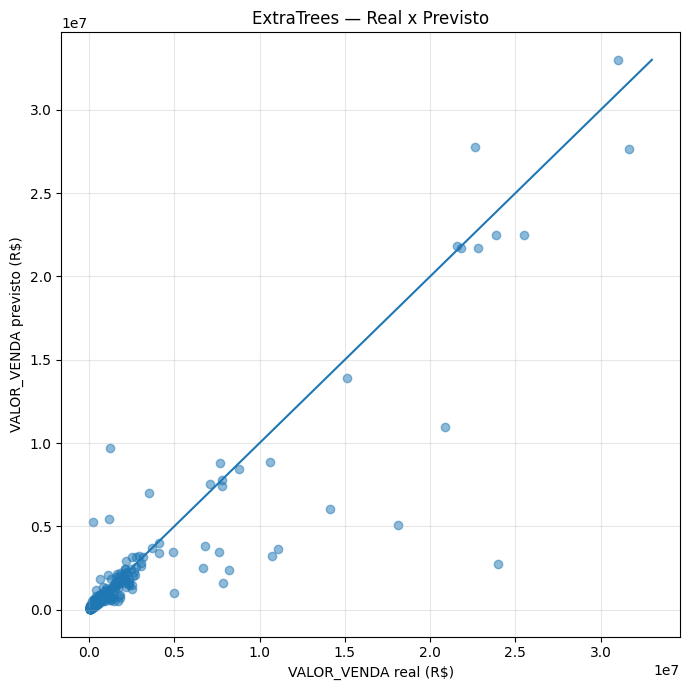

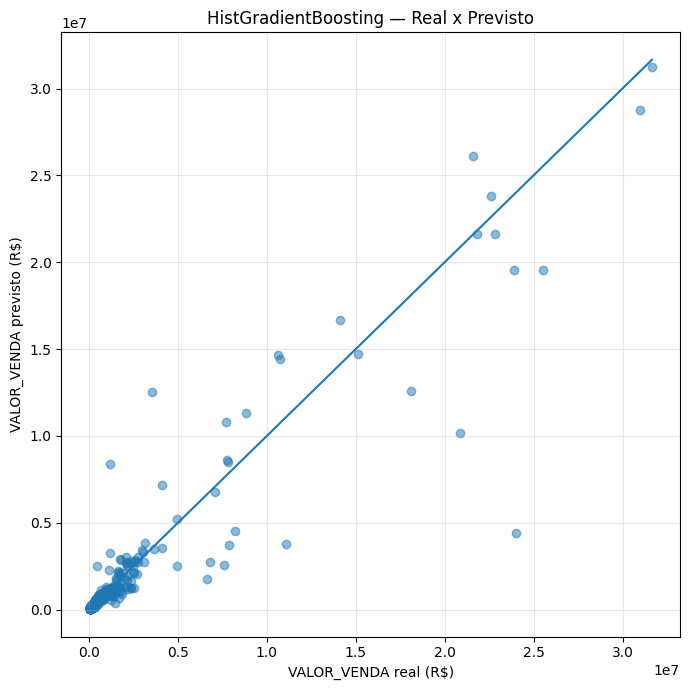

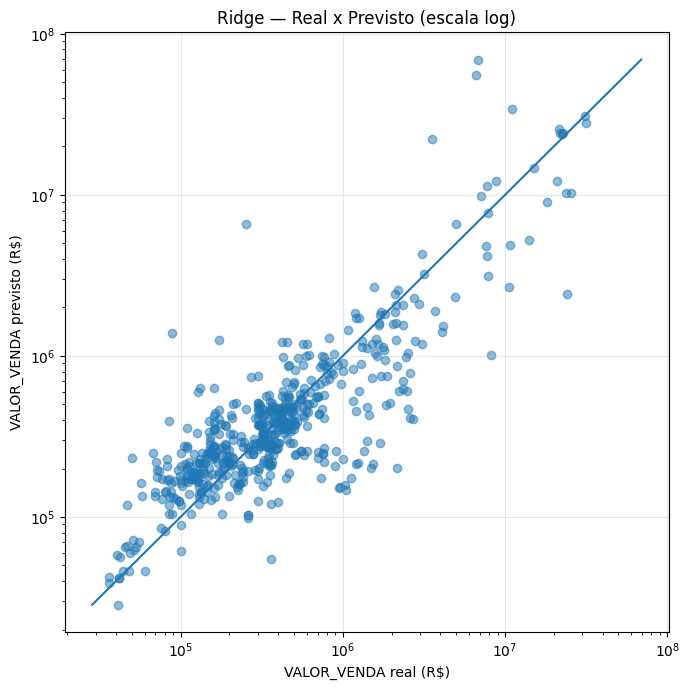

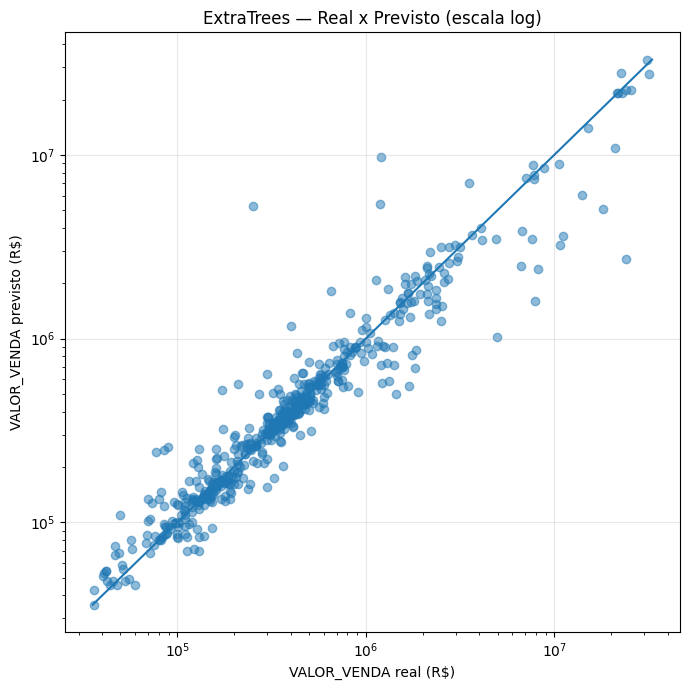

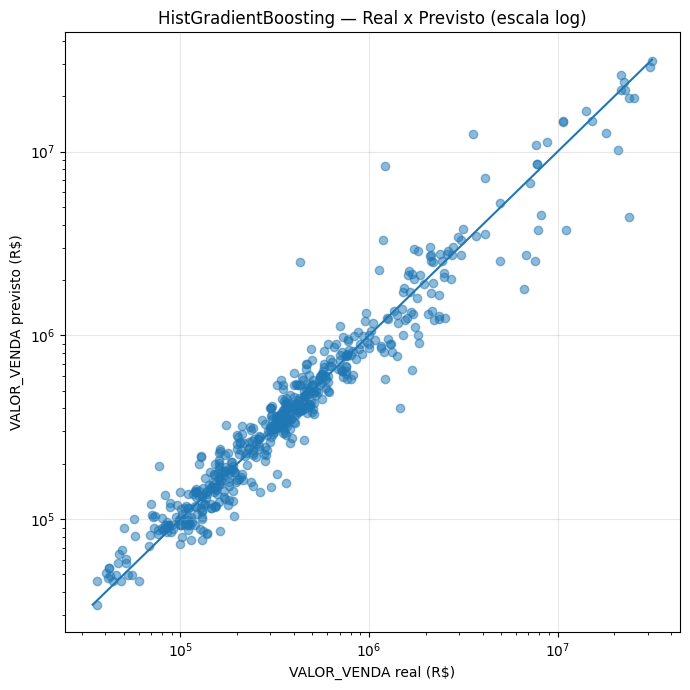

In [19]:
# Garanta que os pipes já estão treinados (rápido)
pipe_ridge_best.fit(X_train, y_train_log)
pipe_et_best.fit(X_train, y_train_log)
pipe_hgb_best.fit(X_train, y_train_log)

# Previsões (voltando do log para R$)
pred_ridge = np.expm1(pipe_ridge_best.predict(X_test))
pred_et    = np.expm1(pipe_et_best.predict(X_test))
pred_hgb   = np.expm1(pipe_hgb_best.predict(X_test))

def scatter_real_vs_prev(y_true, y_pred, titulo, log_scale=False):
    plt.figure(figsize=(7, 7))

    # pontos: Real (x) vs Previsto (y)
    plt.scatter(y_true, y_pred, alpha=0.5)

    # linha y=x
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx])

    if log_scale:
        plt.xscale("log")
        plt.yscale("log")

    plt.title(titulo)
    plt.xlabel("VALOR_VENDA real (R$)")
    plt.ylabel("VALOR_VENDA previsto (R$)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 1) Escala normal
scatter_real_vs_prev(y_test.values, pred_ridge, "Ridge — Real x Previsto", log_scale=False)
scatter_real_vs_prev(y_test.values, pred_et, "ExtraTrees — Real x Previsto", log_scale=False)
scatter_real_vs_prev(y_test.values, pred_hgb, "HistGradientBoosting — Real x Previsto", log_scale=False)

# 2) (Opcional, recomendado) Escala log para enxergar melhor todas as faixas de preço
scatter_real_vs_prev(y_test.values, pred_ridge, "Ridge — Real x Previsto (escala log)", log_scale=True)
scatter_real_vs_prev(y_test.values, pred_et, "ExtraTrees — Real x Previsto (escala log)", log_scale=True)
scatter_real_vs_prev(y_test.values, pred_hgb, "HistGradientBoosting — Real x Previsto (escala log)", log_scale=True)